In [2]:
import json
import os
import sys
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy

from connectivity.curves import CURVES


%load_ext autoreload
%autoreload 2
%aimport connectivity

SOURCE = "../output" # "publish_data/paper"
CURVE_FITTING_RESULT_FILE = f"{SOURCE}/curve_fitting/curve_fitting_lf.json"
RESPONSES_RESULT_FILE = f"{SOURCE}/significant_responses/response_channels_lf.json"
PATIENT_IDS = ["EL019", "EL020", "EL021", "EL022", "EL026", "EL027", "EL028", "EL011", "EL013", "EL014", "EL015", "EL016"]
BASE_PATH = "D:/data_paper"
ATLAS_PATH = "../data/data_atlas.csv"
CURVE = CURVES["5P"]

In [3]:
from connectivity.load import MultipleHDFResponseLoader, get_h5_names_of_patient


responses_df = pd.read_json(RESPONSES_RESULT_FILE)
curve_fitting_df = pd.read_json(CURVE_FITTING_RESULT_FILE)

merged_df = pd.merge(
    responses_df,
    curve_fitting_df,
    on=["patient_id", "stim_channel_name", "response_channel_name"],
)

atlas = pd.read_csv(ATLAS_PATH)

relevant_columns = [
    "name",
    "soz",
    "ied",
    "propagation",
    "epilepsy"
]
x_fit = np.linspace(0, 1, 1000)

result_rows = []


def get_epilepsy_info(channel_name, bipole_mapping, epilepsy_df, relevant_columns):
    """Return merged epilepsy info for a bipolar channel."""
    name_pos = bipole_mapping[channel_name]["name_pos"]
    name_neg = bipole_mapping[channel_name]["name_neg"]

    info_pos = epilepsy_df.loc[epilepsy_df["name"] == name_pos, relevant_columns]
    info_neg = epilepsy_df.loc[epilepsy_df["name"] == name_neg, relevant_columns]
    assert len(info_pos) == 1
    assert len(info_neg) == 1

    info_pos = info_pos.squeeze()
    info_neg = info_neg.squeeze()

    merged = {
        "soz": max(info_pos["soz"], info_neg["soz"]),
        "ied": max(info_pos["ied"], info_neg["ied"]),
        "propagation": max(info_pos["propagation"], info_neg["propagation"]),
        "epilepsy": info_pos["epilepsy"],
    }
    merged["class"] = "soz" if merged["soz"] == True else ("ied" if merged["ied"] == True else ("propagation" if merged["propagation"] == True else "normal"))
    return merged


def get_structure(channel_name, atlas, mrl):
    """Return atlas structure for the given bipolar channel."""
    destrieux_label = mrl.get_destrieux_labels_from_names(
        channel_names=[channel_name], short_form=True
    )[0]

    # special cases
    if destrieux_label == "G_Ins_lg":
        destrieux_label = "G_Ins_lg_and_S_cent_ins"
    elif destrieux_label == "Entorhinal":
        destrieux_label = "entorhinal_cortex"
    elif destrieux_label in ["G_occipital_inf"]: 
        return "Unknown"

    candidate = atlas[atlas["destrieux"] == destrieux_label]
    assert len(candidate) > 0, f"Missing atlas entry for {destrieux_label}"
    return candidate.iloc[0]["structure"]

def add_prefix(d, prefix):
    return {f"{prefix}_{k}": v for k, v in d.items()}


for patient_id in PATIENT_IDS:
    print(f"Processing patient {patient_id}...")
    patient_df = merged_df[merged_df["patient_id"] == patient_id]

    names_h5 = get_h5_names_of_patient(BASE_PATH, patient_id, protocol="CR")
    path_lookup = f"{BASE_PATH}/{patient_id}/Electrodes/Lookup.xlsx"
    paths_h5 = [f"{BASE_PATH}/{patient_id}/Electrophy/{name}.h5" for name in names_h5]
    paths_logs = [f"{BASE_PATH}/{patient_id}/out/{name}_logs.csv" for name in names_h5]

    mrl = MultipleHDFResponseLoader(
        paths_h5=paths_h5,
        paths_logs=paths_logs,
        recording_names=names_h5,
        path_lookup=path_lookup,
    )

    bipole_mapping = mrl.get_bipole_mapping()

    # lookup_path = f"{BASE_PATH}/{patient_id}/Electrodes/Lookup.xlsx"
    # lookup_channels = pd.read_excel(lookup_path, sheet_name="channels")
    # lookup_bipoles  = pd.read_excel(lookup_path, sheet_name="bipoles")

    # bipoles = lookup_bipoles[
    #     (lookup_bipoles["sm_pos"] >= 0)
    #     & (lookup_bipoles["sm_neg"] >= 0)
    # ]

    # sm_to_name_df = lookup_channels[lookup_channels["sm"] >= 0][
    #     ["sm", "name"]
    # ]
    # sm_to_name_mapping = dict(zip(sm_to_name_df["sm"], sm_to_name_df["name"]))

    # bipole_mapping = {
    #     row["name"]: {
    #         "name_pos": sm_to_name_mapping[row["sm_pos"]],
    #         "name_neg": sm_to_name_mapping[row["sm_neg"]],
    #     }
    #     for _, row in bipoles.iterrows()
    # }

    epilepsy_df = pd.read_csv(
        f"{BASE_PATH}/{patient_id}/Electrodes/epilepsy_labels.csv"
    )
    
    stim_channel_names = patient_df["stim_channel_name"].unique()



    for stim_channel_name in stim_channel_names:
        stim_df = patient_df[patient_df["stim_channel_name"] == stim_channel_name]
        significant_responses_df = stim_df[stim_df["is_significant"] == True]
        
        for _, row in significant_responses_df.iterrows():
            name_pos = bipole_mapping[row["response_channel_name"]]["name_pos"]
            name_neg = bipole_mapping[row["response_channel_name"]]["name_neg"]
            stim_name_pos = bipole_mapping[stim_channel_name]["name_pos"]
            stim_name_neg = bipole_mapping[stim_channel_name]["name_neg"]

            # response channel info
            resp_epi = get_epilepsy_info(
                row["response_channel_name"], bipole_mapping, epilepsy_df, relevant_columns
            )

            resp_structure = get_structure(
                row["response_channel_name"], atlas, mrl
            )

            # stim channel info
            stim_epi = get_epilepsy_info(
                stim_channel_name, bipole_mapping, epilepsy_df, relevant_columns
            )

            stim_structure = get_structure(
                stim_channel_name, atlas, mrl
            )

            resp_pref = add_prefix(resp_epi, "resp")
            stim_pref = add_prefix(stim_epi, "stim")
           

            result_rows.append({
                "patient_id": patient_id,
                "stim_channel_name": stim_channel_name,
                "response_channel_name": row["response_channel_name"],

                **resp_pref,
                **stim_pref,

                "resp_structure": resp_structure,
                "stim_structure": stim_structure,

                "exi": row[f"{CURVE['name']}_exi"],
            })

class_order = ["normal", "soz", "propagation", "ied"]
friendly_class_labels = ["Normal", "Seizure onset zone", "Seizure propagation", "Interictal epileptiform discharges"]
friendly_class_labels_dict = dict(zip(class_order, friendly_class_labels))
df_result = pd.DataFrame(result_rows)
df_result["stim_class"] = pd.Categorical(df_result["stim_class"], categories=class_order, ordered=True)
df_result["resp_class"] = pd.Categorical(df_result["resp_class"], categories=class_order, ordered=True)

# merge response + curve fitting

# iterate through patients, stim, significant resp

# calculate ExI, add IED, SOZ, propagation from additional file, and structure


Processing patient EL019...
Processing patient EL020...
Processing patient EL021...
Processing patient EL022...


C:\Users\E1024679\Documents\coherence\connectivity\load.py:705: UserWarning: Not all recordings have the same channel names. We use the first recording as a reference and keep only channels that are available in all recording. Missing channels in recording EL022_20230315_02h33m13_CR: ['traces/bipolar/lead/aH-L/aH-L-3-aH-L-4', 'traces/bipolar/lead/aH-L/aH-L-4-aH-L-5', 'traces/bipolar/lead/aH-L/aH-L-5-aH-L-6', 'traces/bipolar/lead/aH-L/aH-L-7-aH-L-8', 'traces/bipolar/lead/aH-L/aH-L-8-aH-L-9', 'traces/bipolar/lead/aH-L/aH-L-9-aH-L-10']
  warnings.warn(


Processing patient EL026...
Processing patient EL027...
Processing patient EL028...
Processing patient EL011...
Processing patient EL013...
Processing patient EL014...
Processing patient EL015...
Processing patient EL016...


675 563
0 242
80 0


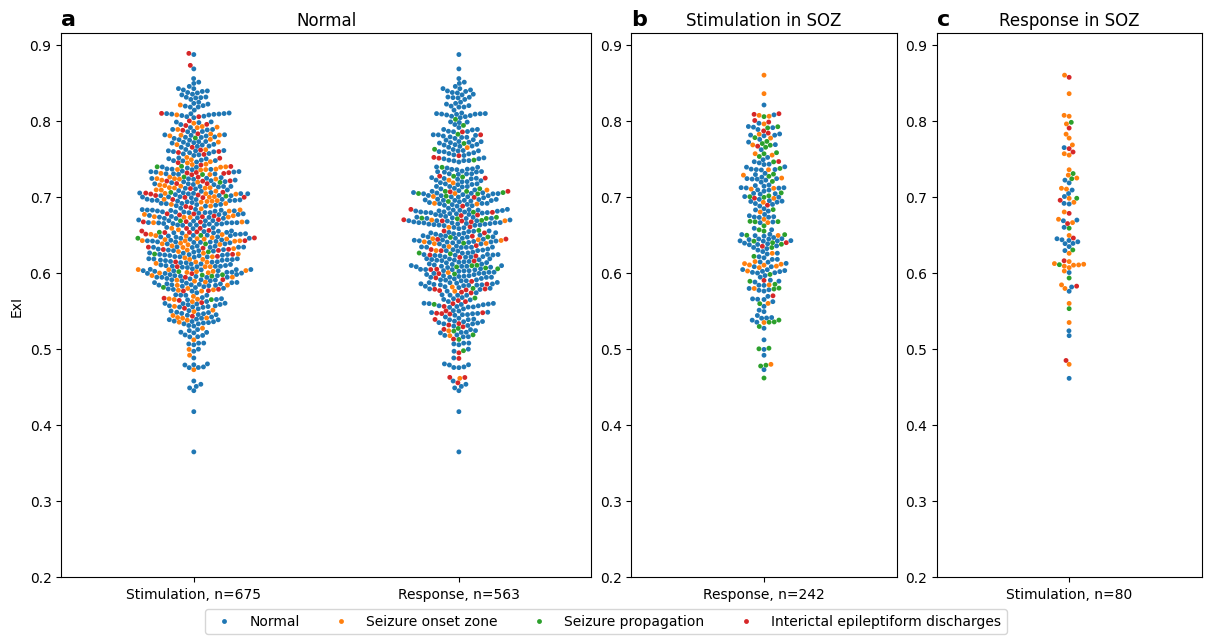

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec


centralized_legend_handles = []
centralized_legend_labels = []

fig = plt.figure(figsize=(12,6), constrained_layout=True)
gs = GridSpec(1, 3, figure=fig, width_ratios=[2, 1, 1])


outgoing_df = df_result.copy()
outgoing_df["direction"] = "Stimulation"
outgoing_df["class"] = outgoing_df["stim_class"]
incoming_df = df_result.copy()
incoming_df["direction"] = "Response"
incoming_df["class"] = incoming_df["resp_class"]
concatenated_df = pd.concat([outgoing_df, incoming_df], ignore_index=True)


# filters = [
#     concatenated_df["stim_class"] == "normal", # all rows
#     concatenated_df["stim_class"] == "soz",
#     concatenated_df["resp_class"] == "soz"
# ]
filters = [
    (outgoing_df["resp_class"] == "normal", incoming_df["stim_class"] == "normal"),
    (pd.Series(False, index=outgoing_df.index), incoming_df["stim_class"] == "soz"),
    (outgoing_df["resp_class"] == "soz", pd.Series(False, index=incoming_df.index))
]

friendly_filter_names = [
    "Normal",
    "Stimulation in SOZ",
    "Response in SOZ"
]
names = ["a", "b", "c"]
first_ax = None
for i_panel, filter_pair in enumerate(filters):
    ax = fig.add_subplot(gs[0, i_panel], sharey=first_ax)

    filtered_out = outgoing_df[filter_pair[0]].copy()
    filtered_in = incoming_df[filter_pair[1]].copy()
    print(len(filtered_out), len(filtered_in))
    filtered_df = pd.concat([filtered_out, filtered_in], ignore_index=True)
    sns.swarmplot(
        data=filtered_df,
        x="direction",
        y="exi",
        hue="class",
        dodge=False,
        size=3.5,
        ax=ax
    )

    ax.set_title(friendly_filter_names[i_panel])
    ax.set_title(names[i_panel], loc='left', fontsize=16, fontweight='bold')
    
    ticklabels = ax.get_xticklabels()
    
    ticks = ax.get_xticks()
    new_labels = []
    for label in ticklabels:
        label_text = label.get_text()
        if label_text == "Stimulation":
            new_labels.append(label_text + f", n={len(filtered_out)}")
        elif label_text == "Response":
            new_labels.append(label_text + f", n={len(filtered_in)}")
    ax.set_xticks(ticks)
    ax.set_xticklabels(new_labels)

    ax.set_xlabel("")
    if i_panel == 0:
        first_ax = ax
        handles, labels = ax.get_legend_handles_labels()
        new_labels = [friendly_class_labels_dict[l] for l in labels]
        #ax.legend(handles, new_labels, loc="lower center")
        centralized_legend_handles.extend(handles)
        centralized_legend_labels.extend(new_labels)
        ax.set_ylabel("ExI")
        ax.set_ylim(bottom=0.2)
    else:
        ax.set_ylabel("")
    ax.legend().remove()

fig.legend(
    centralized_legend_handles,
    centralized_legend_labels,
    loc="lower center",
    ncol=6,
    bbox_to_anchor=(0.5, -0.06),
)

plt.savefig("../output/figures/sfigure12.pdf", bbox_inches='tight', dpi=300)
plt.savefig("../output/figures/sfigure12.svg", bbox_inches='tight', dpi=300)

plt.show() 
    